# Load Libraries

In [10]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

import os
import random

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import Dataset
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Load Dataset

In [12]:
ticker = 'AAPL'
# ticker = "GOOGL"
# ticker = "^IXIC"
# ticker = "^GSPC"
df =  yf.download(ticker, '2013-01-01')
# scaler = StandardScaler()

# df['Close'] = scaler.fit_transform(df['Close'])

[*********************100%***********************]  1 of 1 completed


In [13]:
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# Data Partitioning

In [14]:
# -----------------------------------
# Set input window and forcast horizon length 
# -----------------------------------
input_window = 30
forecast_horizon = 1

# -----------------------------------
# Extract the target close prices
# -----------------------------------
close_prices = df['Close'].values


X = []
y = []

for i in range(len(close_prices) - input_window - forecast_horizon):
    X.append(close_prices[i:i+input_window])
    y.append(close_prices[i+input_window:i+input_window+forecast_horizon])

X = np.array(X)
y = np.array(y)

# -----------------------------------
# Data partitioning 
# -----------------------------------
train_size = int(0.8 * len(X))

X_train = X[:train_size]
X_test = X[train_size:]
y_train = y[:train_size]
y_test = y[train_size:]

# -----------------------------------
# Scale data on training set
# -----------------------------------
scaler = MinMaxScaler()
scaler.fit(X_train.reshape(-1, 1))

X_train = scaler.transform(X_train.reshape(-1, 1)).reshape(X_train.shape)
X_test = scaler.transform(X_test.reshape(-1, 1)).reshape(X_test.shape)

y_train = scaler.transform(y_train.reshape(-1, 1)).reshape(y_train.shape)
y_test = scaler.transform(y_test.reshape(-1, 1)).reshape(y_test.shape)

# -----------------------------------
# Convert data to tensors
# -----------------------------------
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)


X_train = X_train.view(X_train.size(0), input_window, 1)
X_test = X_test.view(X_test.size(0), input_window, 1)


y_train = y_train.squeeze(-1)
y_test = y_test.squeeze(-1)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: torch.Size([2615, 30, 1])
y_train: torch.Size([2615, 1])
X_test : torch.Size([654, 30, 1])
y_test : torch.Size([654, 1])


# Datalaoder

In [15]:
from torch.utils.data import DataLoader

batch_size = 32  

train_dataset = StockDataset(X_train, y_train)
test_dataset = StockDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=True
)


# LSTM Model

In [16]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(LSTMModel, self).__init__()

        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.1)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)

        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])

        return out

# Training and Evaluation

Epoch 000 | Train Loss: 0.009311
Epoch 025 | Train Loss: 0.000679
Epoch 050 | Train Loss: 0.000659
Epoch 075 | Train Loss: 0.000913
Train RMSE: 4.7628
Test RMSE:  27.7104


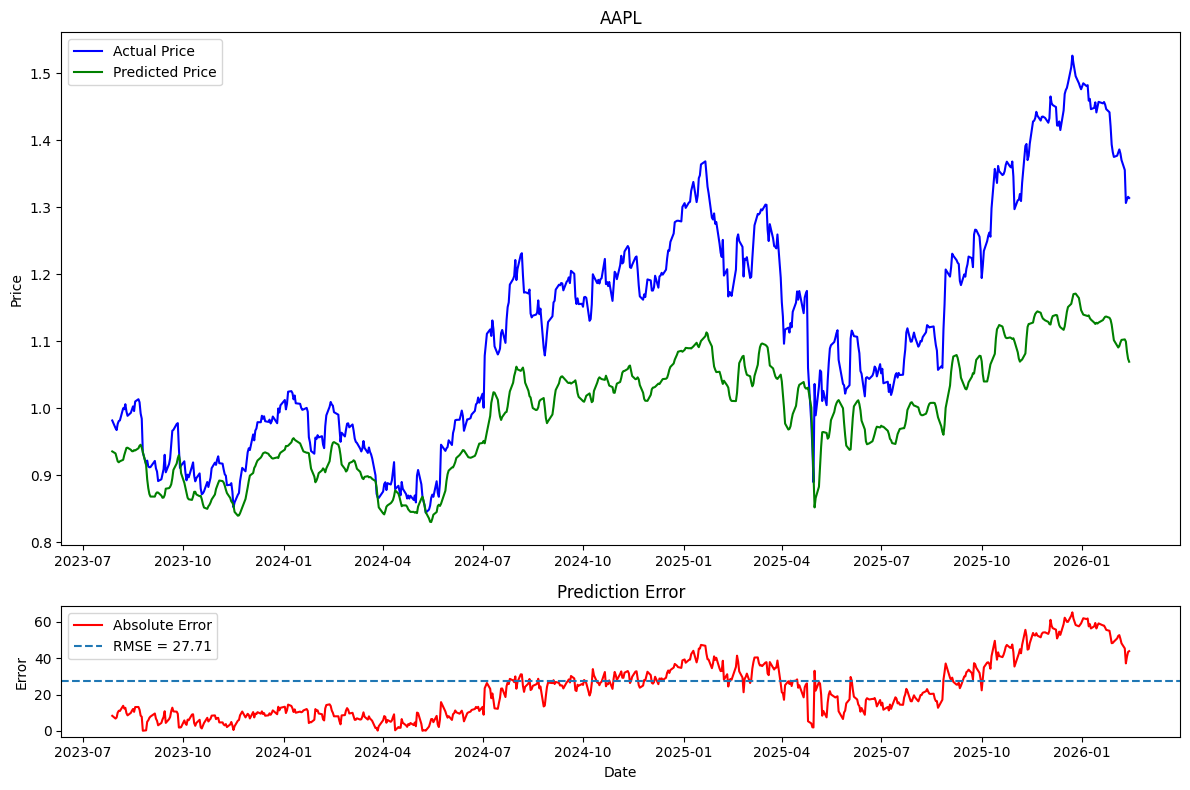

In [17]:
# -----------------------------------
# Training and evaluation
# -----------------------------------

# 1. Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMModel(
    input_dim=1,
    hidden_dim=32,
    num_layers=2,
    output_dim=forecast_horizon
).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)  # safer LR
num_epochs = 100

# -----------------------------------
# Training loop 
# -----------------------------------

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)

    if epoch % 25 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {epoch_loss:.6f}")

# -----------------------------------
# Evaluation
# -----------------------------------

model.eval()

y_train_pred_list = []
y_train_list = []

with torch.no_grad():
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)

        y_train_pred_list.append(preds.cpu())
        y_train_list.append(y_batch.cpu())

y_train_pred = torch.cat(y_train_pred_list, dim=0)
y_train = torch.cat(y_train_list, dim=0)

y_test_pred_list = []
y_test_list = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)

        y_test_pred_list.append(preds.cpu())
        y_test_list.append(y_batch.cpu())

y_test_pred = torch.cat(y_test_pred_list, dim=0)
y_test = torch.cat(y_test_list, dim=0)

# -----------------------------------
# Post-processing
# -----------------------------------

y_train_pred_np = y_train_pred.numpy()
y_train_np = y_train.numpy()
y_test_pred_np = y_test_pred.numpy()
y_test_np = y_test.numpy()

# Inverse scaling
y_train_pred_inv = scaler.inverse_transform(y_train_pred_np)
y_train_inv = scaler.inverse_transform(y_train_np)
y_test_pred_inv = scaler.inverse_transform(y_test_pred_np)
y_test_inv = scaler.inverse_transform(y_test_np)

# RMSE
train_rmse = np.sqrt(np.mean((y_train_inv[:, 0] - y_train_pred_inv[:, 0]) ** 2))
test_rmse = np.sqrt(np.mean((y_test_inv[:, 0] - y_test_pred_inv[:, 0]) ** 2))

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE:  {test_rmse:.4f}")

# -----------------------------------
# Visualization
# -----------------------------------

fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(4, 1)

# Plot 1: Actual vs Predicted
ax1 = fig.add_subplot(gs[:3, 0])
test_dates = df.index[-len(y_test_inv):]

ax1.plot(test_dates, y_test, color='blue', label='Actual Price')
ax1.plot(test_dates, y_test_pred, color='green', label='Predicted Price')

ax1.set_title(f'{ticker}')
ax1.set_ylabel('Price')
ax1.legend()

# Plot 2: Error
ax2 = fig.add_subplot(gs[3, 0])
error = np.abs(y_test_inv[:, 0] - y_test_pred_inv[:, 0])

ax2.plot(test_dates, error, color='red', label='Absolute Error')
ax2.axhline(test_rmse, linestyle='--', label=f'RMSE = {test_rmse:.2f}')

ax2.set_title('Prediction Error')
ax2.set_xlabel('Date')
ax2.set_ylabel('Error')
ax2.legend()

plt.tight_layout()
plt.show()


In [18]:
y_true = y_test
y_pred = y_test_pred

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)

print(f"MSE:  {mse:.4f}")
print(f"MAE:  {mae:.4f}")

rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.4f}")

from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(y_true, y_pred) * 100
print(f"MAPE: {mape:.4f}%")

def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diff = np.abs(y_true - y_pred)
    return 100 * np.mean(np.where(denominator == 0, 0, diff / denominator))

print(f"SMAPE: {smape(y_true, y_pred):.2f}%")

MSE:  0.0238
MAE:  0.1267
RMSE: 0.1543
MAPE: 10.4659%
SMAPE: 11.25%
